# World Cup 2026 Match Predictor

Rerun all cells to download the latest results, refit the model, and predict all upcoming fixtures.

## 1. Data

In [20]:
from data import load

training, upcoming = load()

print(f"Training matches: {len(training)}")
print(f"Date range: {training['date'].min():%Y-%m-%d} to {training['date'].max():%Y-%m-%d}")
print(f"Weight range: {training['weight'].min():.6f} to {training['weight'].max():.6f}")
print(f"Upcoming fixtures: {len(upcoming)}")
upcoming.head(10)

Training matches: 25425
Date range: 2000-01-04 to 2026-07-01
Weight range: 0.000051 to 0.999051
Upcoming fixtures: 11


,date,home_team,away_team,neutral,tournament,city,country
0,2026-07-02,Spain,Austria,True,FIFA World Cup,Inglewood,United States
1,2026-07-02,Portugal,Croatia,True,FIFA World Cup,Toronto,Canada
2,2026-07-02,Switzerland,Algeria,True,FIFA World Cup,Vancouver,Canada
3,2026-07-03,Australia,Egypt,True,FIFA World Cup,Arlington,United States
4,2026-07-03,Argentina,Cape Verde,True,FIFA World Cup,Miami Gardens,United States
5,2026-07-03,Colombia,Ghana,True,FIFA World Cup,Kansas City,United States
6,2026-07-04,Canada,Morocco,True,FIFA World Cup,Houston,United States
7,2026-07-04,Paraguay,France,True,FIFA World Cup,Philadelphia,United States
8,2026-07-05,Brazil,Norway,True,FIFA World Cup,East Rutherford,United States
9,2026-07-05,Mexico,England,False,FIFA World Cup,Mexico City,Mexico


## 2. Model

In [21]:
from model import fit

model = fit(training)

print(f"Converged: {model.converged} | teams: {len(model.teams)} | "
      f"weighted log-likelihood: {model.log_likelihood:.1f}")
print(f"Home advantage: {model.home_adv:.3f} | Dixon-Coles rho: {model.rho:.3f}")
model.ratings().head(15)

Converged: True | teams: 321 | weighted log-likelihood: -3497.7
Home advantage: 0.255 | Dixon-Coles rho: -0.047


,team,attack,defense,strength
0,Argentina,1.113344,1.250528,2.363873
1,Spain,1.195474,0.992579,2.188053
2,Brazil,1.124386,0.933457,2.057843
3,England,0.987262,1.007449,1.994711
4,France,1.083558,0.890205,1.973763
5,Portugal,1.084739,0.842720,1.927459
6,Colombia,0.995956,0.875183,1.871138
7,Morocco,0.788193,1.060081,1.848274
8,Japan,0.984999,0.795190,1.780189
9,Germany,1.144243,0.585927,1.730170


## 3. Backtesting & Calibration

In [22]:
from data import download_results
from backtest import backtest_all

raw = download_results()
summary, records = backtest_all(raw)
summary

,tournament,n,log_loss,ll_uniform,ll_empirical,rps,rps_uniform,rps_empirical,score_hit,score_hit_modal,xg_mae,total_goals_bias
0,WC 2018,48,0.9532,1.0986,1.0656,0.2017,0.2465,0.2481,0.1250,0.0833,0.8194,-0.3779
1,WC 2022,48,1.0756,1.0986,1.0667,0.2334,0.2431,0.2414,0.1250,0.1250,0.9745,-0.3244
2,WC 2026,72,0.8989,1.0986,1.0871,0.1674,0.2315,0.2266,0.0833,0.1250,0.9473,-0.5924
3,pooled,168,0.9649,1.0986,1.0753,0.1961,0.2391,0.2368,0.1071,0.0893,0.9185,-0.4545


Reading the table: `log_loss` / `rps` are the model (lower is better); `ll_*` / `rps_*` columns are the naive baselines it must beat. `score_hit` is the exact-scoreline hit rate vs always guessing the historically most common score. Backtests use group-stage matches only — this dataset records knockout scores *including extra time*, which would mislabel 90-minute draws as wins. The weighting and regularization defaults behind these numbers were tuned by `tune.py` on 28 major-tournament editions 2006–2025 (WC 2026 held out); the model still under-predicts total goals by ~0.4/match, so don't lean on it for totals markets.

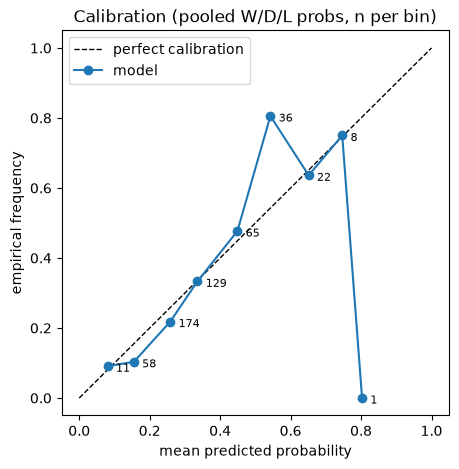

,bin,n,mean_predicted,empirical_rate
0,"[0.0, 0.1)",11,0.080780,0.090909
1,"[0.1, 0.2)",58,0.155202,0.103448
2,"[0.2, 0.3)",174,0.258546,0.218391
3,"[0.3, 0.4)",129,0.335637,0.333333
4,"[0.4, 0.5)",65,0.448989,0.476923
5,"[0.5, 0.6)",36,0.542670,0.805556
6,"[0.6, 0.7)",22,0.651330,0.636364
7,"[0.7, 0.8)",8,0.746623,0.750000
8,"[0.8, 0.9)",1,0.802888,0.000000


In [23]:
import matplotlib.pyplot as plt

from backtest import calibration_table, plot_calibration

plot_calibration(records)
plt.show()
calibration_table(records)

### Market comparison

The baselines above are table stakes — the benchmark that matters for betting is the bookmakers. `odds.py` downloads football-data.co.uk's World Cup workbook (1X2 odds for every 2018/2022/2026 match) and scores the de-vigged market-average probabilities on the same backtest matches. It also simulates flat 1-unit bets on every outcome where the raw model beats the market by ≥5 points, settled at market-average (`_avg`) and best-available (`_max`) prices.

Reading the result: the market still wins on log-loss and RPS pooled (the tuned model takes WC 2018, the market takes 2022 and 2026). Any positive P&L in the sim is longshot variance, not edge — flagged bets average odds of ~6, the pooled z is ~0.7, and a single shock result (South Korea over Germany 2018) accounts for most of the profit. Practical takeaway: an edge flagged by `check_odds` is more likely the model's blind spot than the market's mistake — which is what the recalibration and blend below are for.

In [24]:
from odds import compare_to_market

market_summary, market_merged = compare_to_market(records)
market_summary

,tournament,n,ll_model,ll_market,rps_model,rps_market,n_bets,pnl_avg,roi_avg,pnl_max,roi_max
0,WC 2018,48,0.9532,0.9312,0.2017,0.1960,57,9.26,0.162,20.13,0.353
1,WC 2022,48,1.0756,1.0318,0.2334,0.2228,56,27.05,0.483,35.46,0.633
2,WC 2026,72,0.8989,0.8195,0.1674,0.1433,78,-0.20,-0.003,7.88,0.101
3,pooled,168,0.9649,0.9121,0.1961,0.1810,191,36.11,0.189,63.47,0.332


### Recalibration & market blend

Two fixes layered on the raw model, each judged out-of-sample on the WC 2026 group stage (used for fitting neither layer):

1. **Recalibration** (`calibrate.py`): the calibration table above shows the raw model overstating longshots and understating favorites. Vector scaling (a temperature plus per-outcome offsets, fit on the group stages of 28 major-tournament editions 2006–2025) corrects the 1X2 probabilities.
2. **Market blend** (`odds.py`): a log-space blend of the calibrated model with the de-vigged market average, weight fit on WC 2018+2022 only. The weight says how much the model adds *on top of* the market; the ladder below says whether each layer earns its keep.

In [25]:
from odds import holdout_ladder

ladder, w_blend = holdout_ladder(market_merged)
print(f"blend weight on the model (fit on WC 2018+2022): {w_blend:.2f}")
ladder

blend weight on the model (fit on WC 2018+2022): 0.27


,probs,log_loss,rps
0,model (raw),0.8989,0.1674
1,model (calibrated),0.8954,0.1663
2,market (de-vigged avg),0.8195,0.1433
3,blend (w_model=0.27),0.8270,0.1453


## 4. Today's Predictions

In [26]:
from predict import predict, predict_fixtures

table = predict_fixtures(model, upcoming)
table

,date,match,xg_a,xg_b,score,score_prob,p_win_a,p_draw,p_win_b,p_adv_a,p_adv_b
0,2026-07-02,Spain vs Austria,1.91,0.78,1-0,0.125,0.638,0.222,0.140,0.778,0.222
1,2026-07-02,Portugal vs Croatia,1.59,0.97,1-1,0.125,0.513,0.262,0.224,0.664,0.336
2,2026-07-02,Switzerland vs Algeria,1.47,1.26,1-1,0.126,0.414,0.266,0.320,0.553,0.447
3,2026-07-03,Australia vs Egypt,1.03,0.73,0-0,0.179,0.413,0.340,0.246,0.597,0.403
4,2026-07-03,Argentina vs Cape Verde,2.11,0.37,2-0,0.186,0.781,0.169,0.050,0.900,0.100
5,2026-07-03,Colombia vs Ghana,1.79,0.60,1-0,0.159,0.658,0.229,0.114,0.804,0.196
6,2026-07-04,Canada vs Morocco,0.72,1.15,0-1,0.171,0.225,0.323,0.452,0.369,0.631
7,2026-07-04,Paraguay vs France,0.64,1.46,0-1,0.172,0.159,0.278,0.564,0.270,0.730
8,2026-07-05,Brazil vs Norway,1.95,1.08,1-1,0.107,0.571,0.228,0.201,0.707,0.293
9,2026-07-05,Mexico vs England,0.99,1.15,1-1,0.140,0.304,0.308,0.388,0.452,0.548


In [27]:
for f in upcoming.itertuples(index=False):
    p = predict(model, f.home_team, f.away_team, neutral=bool(f.neutral))
    print(p.summary())
    print()

Spain vs Austria
  Expected goals:  Spain 1.91 — 0.78 Austria
  Most likely FT score: 1-0 (12.5%)
  Win/Draw/Win: 63.8% / 22.2% / 14.0%
  Advances: Spain 77.8%, Austria 22.2%

Portugal vs Croatia
  Expected goals:  Portugal 1.59 — 0.97 Croatia
  Most likely FT score: 1-1 (12.5%)
  Win/Draw/Win: 51.3% / 26.2% / 22.4%
  Advances: Portugal 66.4%, Croatia 33.6%

Switzerland vs Algeria
  Expected goals:  Switzerland 1.47 — 1.26 Algeria
  Most likely FT score: 1-1 (12.6%)
  Win/Draw/Win: 41.4% / 26.6% / 32.0%
  Advances: Switzerland 55.3%, Algeria 44.7%

Australia vs Egypt
  Expected goals:  Australia 1.03 — 0.73 Egypt
  Most likely FT score: 0-0 (17.9%)
  Win/Draw/Win: 41.3% / 34.0% / 24.6%
  Advances: Australia 59.7%, Egypt 40.3%

Argentina vs Cape Verde
  Expected goals:  Argentina 2.11 — 0.37 Cape Verde
  Most likely FT score: 2-0 (18.6%)
  Win/Draw/Win: 78.1% / 16.9% / 5.0%
  Advances: Argentina 90.0%, Cape Verde 10.0%

Colombia vs Ghana
  Expected goals:  Colombia 1.79 — 0.60 Ghana
  M

### Odds check

Type in a bookmaker's decimal odds for the 1X2 (90-minute result) market. The table shows the pipeline from section 3: raw model → calibrated probabilities (`model_cal`) → blend with the de-vigged market at weight `w_blend`. A bet is flagged only when the **calibrated** model beats the market by at least `min_edge` (default 5 points) *and* the blend — the best available probability estimate — still gives positive EV at the offered odds.

Caveats: a *large* edge usually means the market knows team news the model can't see — check that first. The market comparison above backs this up on 168 matches: the de-vigged market average out-predicted the raw model in all three tournaments, so treat flagged edges as hypotheses against you, not free money. Penalties are modeled as a coin flip, so be skeptical of "to qualify" prices. And never bet unders off this model: the backtests measured it under-predicting total goals.

In [34]:
import numpy as np
import pandas as pd

from calibrate import TUNED, apply_calibration
from odds import blend


def check_odds(team_a, team_b, odds_win, odds_draw, odds_loss,
               neutral=True, knockout=True, min_edge=0.05):
    """Show the model's full prediction for a match, then compare bookmaker
    1X2 decimal odds against the calibrated model and the market blend."""
    p = predict(model, team_a, team_b, neutral=neutral, knockout=knockout)

    print(p.summary())
    print()

    outcomes = [f"{team_a} win", "draw", f"{team_b} win"]
    odds = np.array([odds_win, odds_draw, odds_loss], dtype=float)

    implied = 1.0 / odds
    overround = implied.sum()
    market = implied / overround

    raw = np.array([p.p_win_a, p.p_draw, p.p_win_b])
    cal = apply_calibration(raw, TUNED)[0]
    mix = blend(cal[None, :], market[None, :], w_blend)[0]

    table = pd.DataFrame({
        "outcome": outcomes,
        "odds": odds,
        "market_prob": market.round(3),
        "model_raw": raw.round(3),
        "model_cal": cal.round(3),
        "blend_prob": mix.round(3),
        "edge_cal": (cal - market).round(3),
        "ev_blend_$1": (mix * odds - 1).round(3),
    })
    print(f"Bookmaker margin {overround - 1:.1%}, min edge to act {min_edge:.0%}")
    print(table.to_string(index=False))

    flagged = table[(table["edge_cal"] >= min_edge) & (table["ev_blend_$1"] > 0)]
    if flagged.empty:
        print("\nVerdict: NO BET — no outcome clears both the edge threshold "
              "and positive blend EV.")
    else:
        for _, r in flagged.iterrows():
            print(f"\nVerdict: value on {r['outcome']!r} "
                  f"(calibrated edge {r['edge_cal']:+.1%}, "
                  f"blend EV {r['ev_blend_$1']:+.1%} per $1)."
                  f"\n  Before acting: check team news — a gap this size is "
                  f"often the market pricing in something the model can't see.")
    return table


# Example — replace with a real fixture and the odds you see:
check_odds("Paraguay", "France", odds_win=13.00, odds_draw=5.80, odds_loss=1.13, neutral=True, knockout=True, min_edge=0.05);

Paraguay vs France
  Expected goals:  Paraguay 0.64 — 1.46 France
  Most likely FT score: 0-1 (17.2%)
  Win/Draw/Win: 15.9% / 27.8% / 56.4%
  Advances: Paraguay 27.0%, France 73.0%

Bookmaker margin 13.4%, min edge to act 5%
     outcome  odds  market_prob  model_raw  model_cal  blend_prob  edge_cal  ev_blend_$1
Paraguay win 13.00        0.068      0.159      0.146       0.085     0.079        0.105
        draw  5.80        0.152      0.278      0.270       0.181     0.118        0.048
  France win  1.13        0.780      0.564      0.584       0.734    -0.196       -0.170

Verdict: value on 'Paraguay win' (calibrated edge +7.9%, blend EV +10.5% per $1).
  Before acting: check team news — a gap this size is often the market pricing in something the model can't see.

Verdict: value on 'draw' (calibrated edge +11.8%, blend EV +4.8% per $1).
  Before acting: check team news — a gap this size is often the market pricing in something the model can't see.
